1. Импорты, seed и среда

In [1]:
import random
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    pipeline
)

# Настройки отображения для удобства чтения
pd.set_option('display.max_colwidth', 150)
pd.set_option('display.width', 1000)

def set_seed(seed: int = 42) -> None:
    """Фиксация seed для воспроизводимости результатов."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

C:\Users\Gobli\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


2. Данные и первичный анализ (Sanity-check)

In [2]:
# Загрузка рекомендуемого датасета 'emotion' (HuggingFace)
print("Загрузка датасета 'emotion'...")
dataset = load_dataset("emotion")

# Показываем размеры split-частей
print("\nРазмеры датасета:")
for split in dataset.keys():
    print(f"  {split}: {len(dataset[split])} примеров")

# Названия классов и маппинги
label_names = dataset["train"].features["label"].names
id2label = {i: label for i, label in enumerate(label_names)}
label2id = {label: i for i, label in enumerate(label_names)}
print(f"\nКлассы ({len(label_names)}): {label_names}")

# Вывод 5 примеров текстов и меток
print("\nПримеры данных:")
samples = dataset["train"].select(range(5))
for i, sample in enumerate(samples):
    text = sample["text"][:100] + "..." if len(sample["text"]) > 100 else sample["text"]
    print(f"{i+1}. [{id2label[sample['label']]}] {text}")

print("\nЗадача: Классификация эмоциональной окраски текста на 6 классов.")
print("   Датасет уже размечен, содержит короткие пользовательские тексты на английском.")

Загрузка датасета 'emotion'...



Размеры датасета:
  train: 16000 примеров
  validation: 2000 примеров
  test: 2000 примеров

Классы (6): ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

Примеры данных:
1. [sadness] i didnt feel humiliated
2. [sadness] i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and ...
3. [anger] im grabbing a minute to post i feel greedy wrong
4. [love] i am ever feeling nostalgic about the fireplace i will know that it is still on the property
5. [anger] i am feeling grouchy

Задача: Классификация эмоциональной окраски текста на 6 классов.
   Датасет уже размечен, содержит короткие пользовательские тексты на английском.


3. Токенизация (разбор на примерах)

In [3]:
MODEL_NAME = "distilbert-base-uncased"
print(f"Загрузка токенизатора: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

demo_texts = [
    "I love this!",
    "I'm feeling sad today.",
    "This is absolutely amazing!!!"
]

print("\nРазбор токенизации на нескольких примерах:")
for text in demo_texts:
    tokens = tokenizer.tokenize(text)
    input_ids = tokenizer.encode(text, add_special_tokens=True)
    attention_mask = [1] * len(input_ids)
    
    print(f"\nТекст: '{text}'")
    print(f"   Токены (WordPiece): {tokens}")
    print(f"   Input IDs: {input_ids}")
    print(f"   Attention mask: {attention_mask}")
    print(f"   Special tokens: [CLS] в начале, [SEP] в конце")
    print(f"   Decode: '{tokenizer.decode(input_ids)}'")

# Пример работы padding и truncation
print("\nПример padding и truncation:")
batch_texts = ["Short text", "This is a much longer text that demonstrates truncation when max_length is limited."]
encoded_batch = tokenizer(batch_texts, padding=True, truncation=True, max_length=10, return_tensors="pt")

print(f"   Shape после padding/truncation: {encoded_batch['input_ids'].shape}")
print(f"   Attention mask (0 = padding):\n{encoded_batch['attention_mask']}")
print("   Padding добивает короткие последовательности до длины самой длинной в батче.")
print("   Truncation обрезает слишком длинные тексты до max_length.")

Загрузка токенизатора: distilbert-base-uncased

Разбор токенизации на нескольких примерах:

Текст: 'I love this!'
   Токены (WordPiece): ['i', 'love', 'this', '!']
   Input IDs: [101, 1045, 2293, 2023, 999, 102]
   Attention mask: [1, 1, 1, 1, 1, 1]
   Special tokens: [CLS] в начале, [SEP] в конце
   Decode: '[CLS] i love this! [SEP]'

Текст: 'I'm feeling sad today.'
   Токены (WordPiece): ['i', "'", 'm', 'feeling', 'sad', 'today', '.']
   Input IDs: [101, 1045, 1005, 1049, 3110, 6517, 2651, 1012, 102]
   Attention mask: [1, 1, 1, 1, 1, 1, 1, 1, 1]
   Special tokens: [CLS] в начале, [SEP] в конце
   Decode: '[CLS] i ' m feeling sad today. [SEP]'

Текст: 'This is absolutely amazing!!!'
   Токены (WordPiece): ['this', 'is', 'absolutely', 'amazing', '!', '!', '!']
   Input IDs: [101, 2023, 2003, 7078, 6429, 999, 999, 999, 102]
   Attention mask: [1, 1, 1, 1, 1, 1, 1, 1, 1]
   Special tokens: [CLS] в начале, [SEP] в конце
   Decode: '[CLS] this is absolutely amazing!!! [SEP]'

Пример paddi

4. Инференс готовой модели

In [4]:
print("\nИнференс готовой pretrained-модели...")
# Используем модель, обученную на схожей задаче (эмоции/тональность)
pretrained_model_name = "bhadresh-savani/distilbert-base-uncased-emotion"
clf_pipeline = pipeline("text-classification", model=pretrained_model_name, device=0 if torch.cuda.is_available() else -1)

test_inference_texts = [
    "I am so happy right now!",
    "This makes me really angry.",
    "I feel nothing, just neutral.",
    "What a wonderful surprise!",
    "I'm scared of what might happen."
]

results = clf_pipeline(test_inference_texts)
for text, res in zip(test_inference_texts, results):
    print(f"📄 '{text}' → {res['label']} (confidence: {res['score']:.3f})")

print("\nАнализ пригодности:")
print(" Модель уже решает задачу классификации эмоций, домен частично совпадает.")
print(" Набор классов и распределение данных могут отличаться от нашего датасета.")
print(" Для точной настройки на конкретное распределение меток требуется fine-tuning.")


Инференс готовой pretrained-модели...


Loading weights: 100%|████████████████████████████████████████████████████████████| 104/104 [00:00<00:00, 18262.06it/s]


📄 'I am so happy right now!' → joy (confidence: 0.999)
📄 'This makes me really angry.' → anger (confidence: 0.998)
📄 'I feel nothing, just neutral.' → joy (confidence: 0.998)
📄 'What a wonderful surprise!' → joy (confidence: 0.996)
📄 'I'm scared of what might happen.' → fear (confidence: 0.997)

Анализ пригодности:
 Модель уже решает задачу классификации эмоций, домен частично совпадает.
 Набор классов и распределение данных могут отличаться от нашего датасета.
 Для точной настройки на конкретное распределение меток требуется fine-tuning.


5. Fine-tuning для классификации текста

In [5]:
# Подготовка токенизации датасета
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, max_length=128)

print("Токенизация датасета...")
tokenized_datasets = dataset.map(tokenize_function, batched=True, remove_columns=["text"])
# Trainer ожидает колонку 'labels', а в dataset она называется 'label'
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")

print(f"Токенизировано. Train: {len(tokenized_datasets['train'])}, Val: {len(tokenized_datasets['validation'])}, Test: {len(tokenized_datasets['test'])}")

# Загрузка модели для fine-tuning
print(f"\nЗагрузка модели: {MODEL_NAME}")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True  # Игнорируем несовпадение размеров классификационной головы
)
model.to(device)

# Метрики
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted")
    }

# Параметры обучения (совместимость с transformers >=4.30 и <4.30)
common_args = dict(
    output_dir="./outputs/HW13",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=10,
    report_to="none",
    seed=42
)

try:
    training_args = TrainingArguments(eval_strategy="epoch", **common_args)
except TypeError:
    training_args = TrainingArguments(evaluation_strategy="epoch", **common_args)

try:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        processing_class=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=compute_metrics
    )
except TypeError:
    trainer = Trainer(
        model=model, args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        tokenizer=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=compute_metrics
    )

# Запуск обучения
print("\nЗапуск fine-tuning...")
train_result = trainer.train()
print(f"Обучение завершено. Final train loss: {train_result.metrics['train_loss']:.4f}")

Токенизация датасета...


Map: 100%|████████████████████████████████████████████████████████████████| 2000/2000 [00:00<00:00, 8262.53 examples/s]


Токенизировано. Train: 16000, Val: 2000, Test: 2000

Загрузка модели: distilbert-base-uncased


Loading weights: 100%|█████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 5134.86it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Запуск fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.239182,0.200374,0.923000,0.897222,0.923859
2,0.159124,0.167085,0.936500,0.912250,0.935985
3,0.138887,0.158856,0.938500,0.914515,0.938733


Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.65it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Обучение завершено. Final train loss: 0.2496


6. Оценка качества и базовый анализ ошибок


Оценка на validation...
   Accuracy: 0.9385 | F1 Macro: 0.9145

Финальная оценка на test (один раз)...
   Accuracy: 0.9270 | F1 Macro: 0.8821

Classification Report (test):
              precision    recall  f1-score   support

     sadness       0.96      0.96      0.96       581
         joy       0.95      0.95      0.95       695
        love       0.84      0.84      0.84       159
       anger       0.92      0.91      0.91       275
        fear       0.86      0.95      0.90       224
    surprise       0.83      0.65      0.73        66

    accuracy                           0.93      2000
   macro avg       0.89      0.88      0.88      2000
weighted avg       0.93      0.93      0.93      2000


confusion_matrix.png сохранён в artifacts/


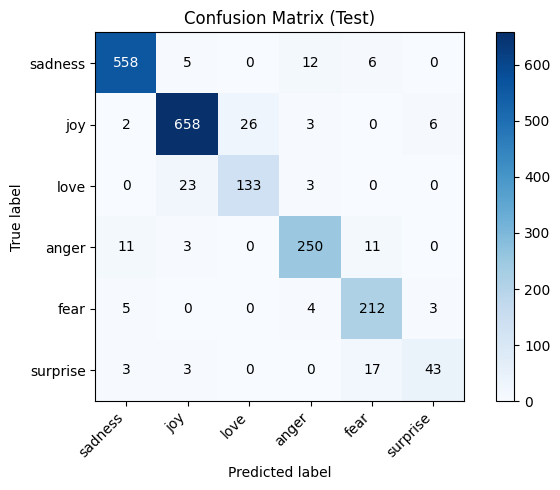

In [6]:
# Обходной путь для transformers >= 5.x (NotebookProgressCallback падает при standalone evaluate)
try:
    from transformers.utils.notebook import NotebookProgressCallback
    trainer.remove_callback(NotebookProgressCallback)
except:
    pass

# Оценка
print("\nОценка на validation...")
val_results = trainer.evaluate(tokenized_datasets["validation"])
print(f"   Accuracy: {val_results['eval_accuracy']:.4f} | F1 Macro: {val_results['eval_f1_macro']:.4f}")

print("\nФинальная оценка на test (один раз)...")
test_results = trainer.evaluate(tokenized_datasets["test"])
print(f"   Accuracy: {test_results['eval_accuracy']:.4f} | F1 Macro: {test_results['eval_f1_macro']:.4f}")

# Детальный отчёт
test_output = trainer.predict(tokenized_datasets["test"])
test_preds = np.argmax(test_output.predictions, axis=-1)
test_labels = test_output.label_ids

print("\nClassification Report (test):")
print(classification_report(test_labels, test_preds, target_names=label_names, zero_division=0))

# Матрица ошибок
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(7, 5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Test)")
plt.colorbar()
tick_marks = np.arange(len(label_names))
plt.xticks(tick_marks, label_names, rotation=45, ha='right')
plt.yticks(tick_marks, label_names)
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")
plt.ylabel("True label"); plt.xlabel("Predicted label")
plt.tight_layout()

os.makedirs("artifacts", exist_ok=True)
plt.savefig("artifacts/confusion_matrix.png", dpi=150, bbox_inches='tight')
print("\nconfusion_matrix.png сохранён в artifacts/")
plt.show()

Сохранение артефактов и анализ предсказаний

In [7]:
print("\nФормирование sample_predictions.csv и анализ ошибок...")
test_df = dataset["test"].to_pandas()
test_df["pred_label"] = [id2label[p] for p in test_preds]
test_df["true_label"] = [id2label[l] for l in test_labels]

# Уверенность модели (confidence)
probs = torch.softmax(torch.tensor(test_output.predictions), dim=-1).numpy()
test_df["confidence"] = [float(probs[i, test_preds[i]]) for i in range(len(test_preds))]

# Сохраняем CSV (минимум text, true_label, pred_label + confidence)
sample_preds = test_df[["text", "true_label", "pred_label", "confidence"]].head(100)
sample_preds.to_csv("artifacts/sample_predictions.csv", index=False, encoding="utf-8")
print("artifacts/sample_predictions.csv сохранён")

# Вывод примеров
print("\nПримеры предсказаний модели:")
display(sample_preds.head(5).style.set_properties(**{'text-align': 'left'}))

# Анализ ошибок
errors = test_df[test_df["true_label"] != test_df["pred_label"]]
print(f"\nНайдено ошибок: {len(errors)} из {len(test_df)} ({100*len(errors)/len(test_df):.1f}%)")
if len(errors) > 0:
    print("\nРазбор нескольких ошибок/пограничных случаев:")
    for _, row in errors.head(5).iterrows():
        t_short = row["text"][:70] + "..." if len(row["text"]) > 70 else row["text"]
        print(f" '{t_short}'")
        print(f"   True: {row['true_label']} | Pred: {row['pred_label']} (conf: {row['confidence']:.3f})\n")
    print("Комментарий:")
    print("Эмоции семантически пересекаются (например, sadness ↔ anger или joy ↔ love).")
    print("Короткие или эмоционально нейтральные тексты сложнее классифицировать.")
    print("Модель иногда путает интенсивность эмоции с самим типом эмоции.")


Формирование sample_predictions.csv и анализ ошибок...
artifacts/sample_predictions.csv сохранён

Примеры предсказаний модели:


,text,true_label,pred_label,confidence
0,im feeling rather rotten so im not very ambitious right now,sadness,sadness,0.998930
1,im updating my blog because i feel shitty,sadness,sadness,0.999121
2,i never make her separate from me because i don t ever want her to feel like i m ashamed with her,sadness,sadness,0.999136
3,i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived,joy,joy,0.998764
4,i was feeling a little vain when i did this one,sadness,sadness,0.999072



Найдено ошибок: 146 из 2000 (7.3%)

Разбор нескольких ошибок/пограничных случаев:
 'i don t feel particularly agitated'
   True: fear | Pred: anger (conf: 0.896)

 'i feel i have to agree with her even though i can imagine some rather ...'
   True: sadness | Pred: joy (conf: 0.781)

 'i feel a bit stressed even though all the things i have going on are f...'
   True: anger | Pred: sadness (conf: 0.609)

 'i am right handed however i play billiards left handed naturally so me...'
   True: surprise | Pred: fear (conf: 0.769)

 'i feel like i am in paradise kissing those sweet lips make me feel lik...'
   True: joy | Pred: love (conf: 0.855)

Комментарий:
Эмоции семантически пересекаются (например, sadness ↔ anger или joy ↔ love).
Короткие или эмоционально нейтральные тексты сложнее классифицировать.
Модель иногда путает интенсивность эмоции с самим типом эмоции.



Визуализация кривых обучения...
artifacts/training_curves.png сохранён


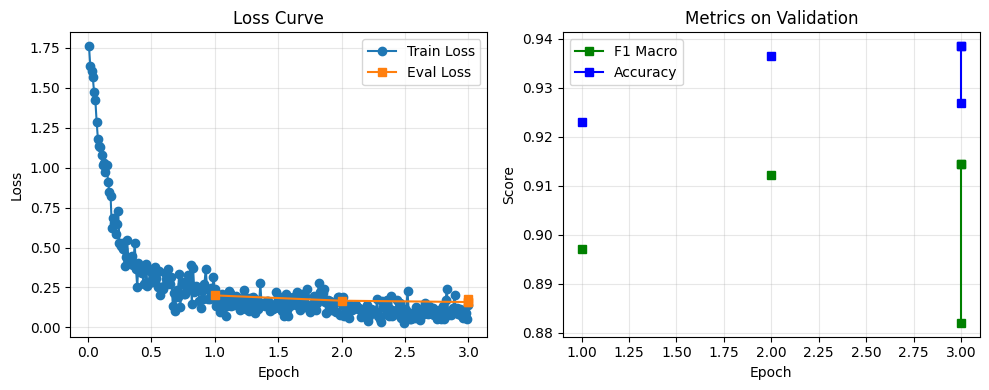

In [8]:
print("\nВизуализация кривых обучения...")
history = pd.DataFrame(trainer.state.log_history)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
if "loss" in history.columns:
    plt.plot(history.dropna(subset=["loss"])["epoch"], history.dropna(subset=["loss"])["loss"], label="Train Loss", marker="o")
if "eval_loss" in history.columns:
    plt.plot(history.dropna(subset=["eval_loss"])["epoch"], history.dropna(subset=["eval_loss"])["eval_loss"], label="Eval Loss", marker="s")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss Curve"); plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for col, lbl, c in [("eval_f1_macro", "F1 Macro", "green"), ("eval_accuracy", "Accuracy", "blue")]:
    if col in history.columns:
        plt.plot(history["epoch"], history[col], label=lbl, marker="s", color=c)
plt.xlabel("Epoch"); plt.ylabel("Score"); plt.title("Metrics on Validation"); plt.legend(); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("artifacts/training_curves.png", dpi=150, bbox_inches='tight')
print("artifacts/training_curves.png сохранён")
plt.show()

In [9]:
print(f"Итоговые метрики на test:")
print(f" Accuracy:  {test_results['eval_accuracy']:.4f}")
print(f" F1 Macro:  {test_results['eval_f1_macro']:.4f}")
print(f"\nАртефакты созданы:")
print(f"   • artifacts/sample_predictions.csv")
print(f"   • artifacts/confusion_matrix.png")
print(f"   • artifacts/training_curves.png")

Итоговые метрики на test:
 Accuracy:  0.9270
 F1 Macro:  0.8821

Артефакты созданы:
   • artifacts/sample_predictions.csv
   • artifacts/confusion_matrix.png
   • artifacts/training_curves.png
